# Notebook 01 – Dataset Exploration

**RAGScope · MSc Data Science Dissertation · Leeds Beckett University · 2026**

---

## Purpose

This notebook provides a systematic exploration of the BioASQ benchmark dataset used in the RAGScope evaluation, accessed via `rag-datasets/rag-mini-bioasq`. The evaluation spans three query *roles*, derived from BioASQ's own challenge structure and drawn from a single biomedical corpus:

| Role | Query Type | Queries | Selection Criterion |
|---|---|:---:|---|
| Phase A | Passage retrieval | 60 | Stratified by relevance-judgement count |
| Factoid | Short exact-answer QA | 40 | Short answer (≤ 6 words) |
| Summary | Multi-passage synthesis | 100 | Long-form or yes/no answer |

### Objectives

1. Profile raw text characteristics (length distributions, vocabulary) of the BioASQ corpus
2. Verify the loader, cleaning, and chunking pipelines work correctly against real BioASQ data
3. Inspect query role distributions and ground-truth answer characteristics
4. Analyse the ingested ChromaDB collection and BM25 corpus statistics
5. Validate that the benchmark query set is properly stratified and that the three role pools are disjoint

### Prerequisites

Run these steps before executing this notebook:
```bash
# Download BioASQ
uv run python data/loaders/download_all.py

# Ingest into ChromaDB and build BM25 index
uv run python pipeline/ingestion.py --corpus bioasq
```


## 0. Setup and Imports

In [1]:
import sys
import json
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import tiktoken

# Add project root to path to import RAGScope modules
PROJECT_ROOT = Path("..")
sys.path.insert(0, str(PROJECT_ROOT))

from config.settings import settings
from data.preprocessing.cleaner import clean, is_meaningful
from data.preprocessing.chunker import TokenChunker

# Plot style
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
PURPLE = "#522D80"
TEAL   = "#17a2b8"
AMBER  = "#f39c12"
BLUE   = "#2C7BE5"
GREEN  = "#008000"
PINK   = "#E685AC"
RED    = "#e74c3c"
PALETTE = [BLUE, GREEN, PINK, AMBER]

SEED = settings.experiment_random_seed
print(f"Project root : {PROJECT_ROOT.resolve()}")
print(f"Random seed  : {SEED}")


Project root : /app
Random seed  : 42


## 1. BioASQ — Corpus and Query Role Analysis

> **Note on role reconstruction:** `rag-mini-bioasq` carries no official BioASQ question-type label (no factoid/list/summary/yesno annotation), so the three roles below are reconstructed from answer shape and relevance-judgement count (see `data/loaders/bioasq.py::_build_role_pools` and `docs/datasets.md`). The three loader functions below are guaranteed to return disjoint query sets for the same seed — verified empirically in the cell below, not just asserted.

In [2]:
from data.loaders.bioasq import load_corpus, load_phase_a_queries, load_factoid_queries, load_summary_queries

print("Loading BioASQ corpus (full, cleaned) ...")
corpus = load_corpus()
phase_a_queries = load_phase_a_queries(sample_size=60, seed=SEED)
factoid_queries = load_factoid_queries(sample_size=40, seed=SEED)
summary_queries = load_summary_queries(sample_size=100, seed=SEED)

sample_passage = corpus[0]
sample_query = phase_a_queries[0]

print(f"\nCorpus passages : {len(corpus):,}")
print(f"Phase A queries : {len(phase_a_queries):,}")
print(f"Factoid queries : {len(factoid_queries):,}")
print(f"Summary queries : {len(summary_queries):,}")

print(f"\nExample passage:")
print(f"  id     : {sample_passage['id']}")
print(f"  text   : {sample_passage['text'][:150]}...")
print(f"  dataset: {sample_passage['dataset']}")

print(f"\nExample query:")
print(f"  id         : {sample_query['id']}")
print(f"  query      : {sample_query['query']}")
print(f"  query_type : {sample_query['query_type']}")

# Disjointness check — the property the role-mapping heuristic depends on
ids_a = {q["id"] for q in phase_a_queries}
ids_f = {q["id"] for q in factoid_queries}
ids_s = {q["id"] for q in summary_queries}
print(f"\nDisjointness check:")
print(f"  Phase A \u2229 Factoid : {ids_a & ids_f} (expect empty set)")
print(f"  Phase A \u2229 Summary : {ids_a & ids_s} (expect empty set)")
print(f"  Factoid \u2229 Summary : {ids_f & ids_s} (expect empty set)")


2026-08-13 04:28:55.401 | INFO     | data.loaders.bioasq:load_corpus:110 - Loading BioASQ corpus (full text-corpus config) …


Loading BioASQ corpus (full, cleaned) ...


README.md:   0%|          | 0.00/813 [00:00<?, ?B/s]

2026-08-13 04:28:59.603 | INFO     | data.loaders.bioasq:load_corpus:129 - BioASQ corpus loaded: 27,972 passages.


2026-08-13 04:29:00.663 | DEBUG    | data.loaders.bioasq:_build_role_pools:299 - BioASQ role pools built: factoid=256, yesno=802, summary_long=50, phase_a_single=677, phase_a_multi=2934.


...

2026-08-13 04:29:01.798 | DEBUG    | data.loaders.bioasq:_build_role_pools:299 - BioASQ role pools built: factoid=256, yesno=802, summary_long=50, phase_a_single=677, phase_a_multi=2934.


2026-08-13 04:29:01.799 | INFO     | data.loaders.bioasq:load_factoid_queries:183 - BioASQ factoid queries loaded: 40.


2026-08-13 04:29:02.769 | DEBUG    | data.loaders.bioasq:_build_role_pools:299 - BioASQ role pools built: factoid=256, yesno=802, summary_long=50, phase_a_single=677, phase_a_multi=2934.


2026-08-13 04:29:02.771 | INFO     | data.loaders.bioasq:load_summary_queries:213 - BioASQ summary queries loaded: 50 yes/no, 50 summary.



Corpus passages : 27,972
Phase A queries : 60
Factoid queries : 40
Summary queries : 100

Example passage:
  id     : 9797
  text   : New data on viruses isolated from patients with subacute thyroiditis de Quervain 
are reported. Characteristic morphological, cytological, some physic...
  dataset: bioasq

Example query:
  id         : 152
  query      : What is known about clinical efficacy of ceftriaxone for treatment of amyotrophic lateral sclerosis?
  query_type : multi_relevant

Disjointness check:
  Phase A ∩ Factoid : set() (expect empty set)
  Phase A ∩ Summary : set() (expect empty set)
  Factoid ∩ Summary : set() (expect empty set)


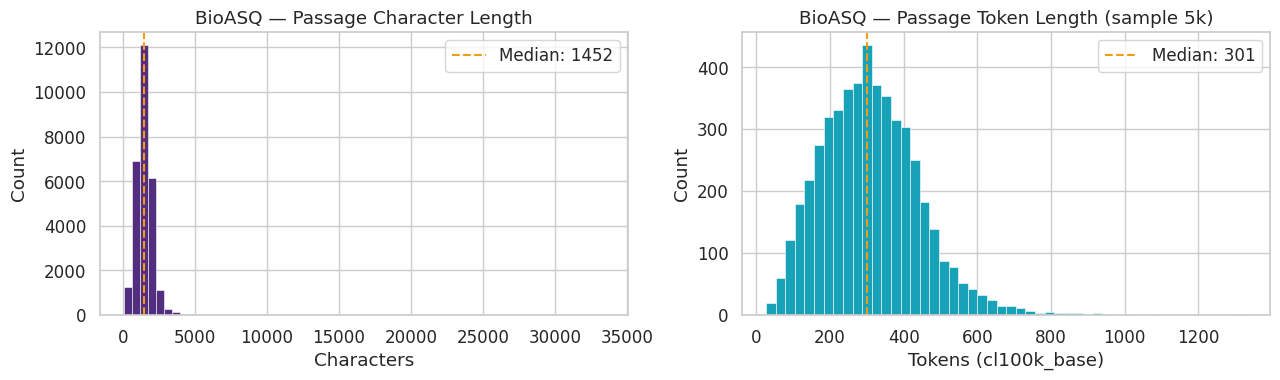

Char length  — mean: 1481, median: 1452, p95: 2350
Token length — mean: 311, median: 301, p95: 543


In [3]:
# ── BioASQ: passage length distributions ─────────────────────────────────────────
enc = tiktoken.get_encoding("cl100k_base")

char_lengths  = [len(p["text"]) for p in corpus]
token_lengths = [len(enc.encode(p["text"])) for p in corpus[:5_000]]  # sample for speed

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(char_lengths, bins=60, color=PURPLE, edgecolor="white", linewidth=0.4)
axes[0].set_title("BioASQ — Passage Character Length")
axes[0].set_xlabel("Characters")
axes[0].set_ylabel("Count")
axes[0].axvline(np.median(char_lengths), color=AMBER, linestyle="--",
                label=f"Median: {np.median(char_lengths):.0f}")
axes[0].legend()

axes[1].hist(token_lengths, bins=50, color=TEAL, edgecolor="white", linewidth=0.4)
axes[1].set_title("BioASQ — Passage Token Length (sample 5k)")
axes[1].set_xlabel("Tokens (cl100k_base)")
axes[1].set_ylabel("Count")
axes[1].axvline(np.median(token_lengths), color=AMBER, linestyle="--",
                label=f"Median: {np.median(token_lengths):.0f}")
axes[1].legend()

plt.tight_layout()
plt.savefig("../experiments/results/fig_bioasq_lengths.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Char length  \u2014 mean: {np.mean(char_lengths):.0f}, "
      f"median: {np.median(char_lengths):.0f}, "
      f"p95: {np.percentile(char_lengths, 95):.0f}")
print(f"Token length \u2014 mean: {np.mean(token_lengths):.0f}, "
      f"median: {np.median(token_lengths):.0f}, "
      f"p95: {np.percentile(token_lengths, 95):.0f}")


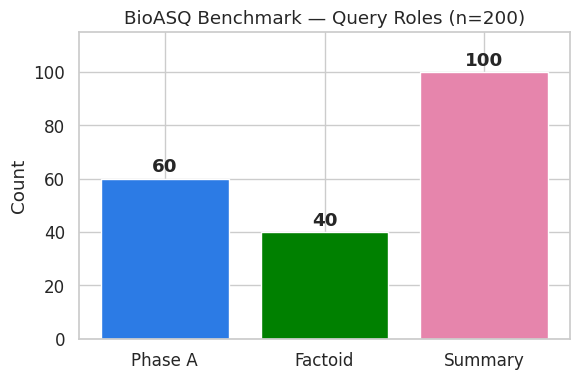

Role distribution:
  Phase A       60  (30%)
  Factoid       40  (20%)
  Summary      100  (50%)

Phase A sub-strata : {'multi_relevant': 30, 'single_relevant': 30}
Summary sub-strata : {'yesno': 50, 'summary': 50}


In [4]:
# ── Query role distribution (n=200 total, 3 roles) ───────────────────────
role_counts = {"Phase A": len(phase_a_queries), "Factoid": len(factoid_queries), "Summary": len(summary_queries)}

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(role_counts.keys(), role_counts.values(), color=[BLUE, GREEN, PINK], edgecolor="white")
for bar, count in zip(bars, role_counts.values()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            str(count), ha="center", va="bottom", fontweight="bold")
ax.set_title("BioASQ Benchmark — Query Roles (n=200)")
ax.set_ylabel("Count")
ax.set_ylim(0, 115)
plt.tight_layout()
plt.show()

print("Role distribution:")
for role, n in role_counts.items():
    print(f"  {role:<12} {n:>3}  ({n/200*100:.0f}%)")

# Sub-stratification within Phase A and Summary
pa_types = Counter(q["query_type"] for q in phase_a_queries)
su_types = Counter(q["query_type"] for q in summary_queries)
print(f"\nPhase A sub-strata : {dict(pa_types)}")
print(f"Summary sub-strata : {dict(su_types)}")


## 2. Factoid Role — Short Exact-Answer Analysis

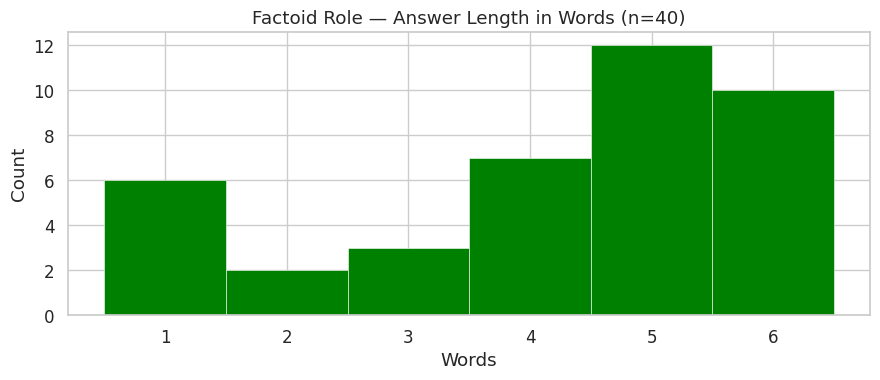

Answer length — mean: 4.2, median: 5, max: 6 words
(All ≤ 6 words by construction — that's the factoid role's selection criterion.)


In [5]:
# ── Factoid: answer length distribution ───────────────────────────────
factoid_answer_lengths = [len(q["answers"][0].split()) for q in factoid_queries]

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(factoid_answer_lengths, bins=range(1, 8), color=GREEN, edgecolor="white", linewidth=0.4, align="left")
ax.set_title("Factoid Role — Answer Length in Words (n=40)")
ax.set_xlabel("Words")
ax.set_ylabel("Count")
ax.set_xticks(range(1, 7))
plt.tight_layout()
plt.show()

print(f"Answer length \u2014 mean: {np.mean(factoid_answer_lengths):.1f}, "
      f"median: {np.median(factoid_answer_lengths):.0f}, "
      f"max: {max(factoid_answer_lengths)} words")
print(f"(All \u2264 6 words by construction \u2014 that's the factoid role's selection criterion.)")


In [6]:
# ── Factoid: sample of queries and answers ──────────────────────
factoid_df = pd.DataFrame([
    {"query": q["query"][:80], "answer": q["answers"][0], "n_relevant": len(q["relevant_passage_ids"])}
    for q in factoid_queries[:10]
])
factoid_df


,query,answer,n_relevant
0,Which syndromes are caused by LAMA1 mutations?,Poretti-Boltshauser and Joubert syndromes,2
1,Are there drugs for Tick-borne Encephalitis?,No drug therapy available today,20
2,Which R package could be used for the identifi...,MethPed,1
3,What is the inheritance pattern of Hunter dise...,X- linked recessive,7
4,Does physical activity influence gut hormones?,Yes.,16
5,Does SCRIB deregulation promote cancer?,"Yes, deregulation of scribble promotes cancer.",9
6,Which glands in the bee secretes royal jelly?,hypopharyngeal glands,4
7,What kind of approaches you need to combine in...,"Clinical, radiological and genetic approaches",1
8,Which domain allowing self-association do exis...,PRION PROTEINS,14
9,Does amiodarone affect thyroid hormone recepto...,Yes,4


## 3. Summary Role — Multi-Passage Synthesis Analysis

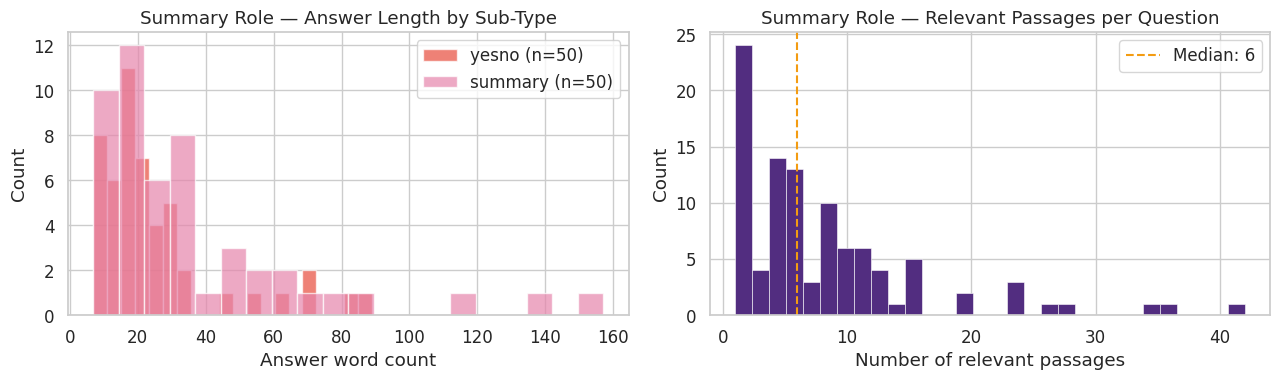

            count   mean        std  min    25%   50%    75%    max
query_type                                                         
summary      50.0  35.46  31.993118  7.0  15.25  24.0  44.25  157.0
yesno        50.0  25.66  19.236031  7.0  14.25  19.5  28.75   89.0


In [7]:
# ── Summary: yes/no vs. free-text complexity ────────────────────────
summary_df = pd.DataFrame(summary_queries)
summary_df["answer_word_count"] = summary_df["answers"].apply(lambda a: len(a[0].split()))
summary_df["n_relevant"] = summary_df["relevant_passage_ids"].apply(len)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for qtype, color in [("yesno", RED), ("summary", PINK)]:
    subset = summary_df[summary_df["query_type"] == qtype]["answer_word_count"]
    axes[0].hist(subset, bins=20, alpha=0.7, color=color, label=f"{qtype} (n={len(subset)})", edgecolor="white")
axes[0].set_title("Summary Role — Answer Length by Sub-Type")
axes[0].set_xlabel("Answer word count")
axes[0].set_ylabel("Count")
axes[0].legend()

axes[1].hist(summary_df["n_relevant"], bins=30, color=PURPLE, edgecolor="white", linewidth=0.4)
axes[1].set_title("Summary Role — Relevant Passages per Question")
axes[1].set_xlabel("Number of relevant passages")
axes[1].set_ylabel("Count")
axes[1].axvline(summary_df["n_relevant"].median(), color=AMBER, linestyle="--",
                 label=f"Median: {summary_df['n_relevant'].median():.0f}")
axes[1].legend()

plt.tight_layout()
plt.savefig("../experiments/results/fig_bioasq_summary_complexity.png", dpi=150, bbox_inches="tight")
plt.show()

print(summary_df.groupby("query_type")["answer_word_count"].describe().to_string())


In [8]:
# ── Summary: sample of queries and answers ───────────────────────
summary_df[["query", "query_type", "n_relevant"]].head(10)


,query,query_type,n_relevant
0,Is there an association between serum interleu...,yesno,6
1,Is nicotinamide effective for skin cancer prev...,yesno,5
2,What is oprozomib?,summary,11
3,Is the TFR1 gene dispensable for erythropoiesis?,yesno,11
4,What is miravirsen?,summary,4
5,List symptoms of 4H leukodystrophy.,summary,8
6,Can mutations in Calmodulin cause ventricular ...,yesno,2
7,Which antiepileptic drug is most strongly asso...,summary,10
8,Are high-flow nasal cannulae effective for tre...,yesno,19
9,Where is the EpCam protein mainly located?,summary,6


## 4. Cleaning and Chunking Pipeline Validation

In [9]:
# ── Test the cleaner on a range of edge cases ───────────────────────
from data.preprocessing.cleaner import clean, is_meaningful

# is_meaningful() rejects anything under 50 characters, so the "should pass"
# cases below are padded past that threshold. The "nan" case is not a
# contrived edge case — it's the real, literal artefact found in 30.4% of
# rag-mini-bioasq's raw corpus rows (see docs/datasets.md), reproduced here
# to document why the meaningfulness filter matters for this dataset.
test_cases = [
    ("<p>Hello <b>world</b> &amp; everything, this is a longer HTML test case</p>", "HTML stripping"),
    ("Caf\u00e9  \t\t  na\u00efve   r\u00e9sum\u00e9 \u2014 testing unicode and whitespace handling at length", "Whitespace + unicode"),
    ("This is a normal, well-formed sentence with enough content to clear the minimum length filter.", "Pass-through"),
    ("nan", "BioASQ's real 'nan' placeholder artefact (30.4% of raw rows)"),
    ("hi", "Too short (meaningfulness filter)"),
]

print(f"{'Input':<50} | {'Cleaned':<50} | {'Meaningful'}")
print("-" * 120)
for raw, label in test_cases:
    cleaned = clean(raw)
    meaningful = is_meaningful(cleaned)
    print(f"[{label}]")
    print(f"  raw     : {repr(raw[:60])}")
    print(f"  cleaned : {repr(cleaned[:60])}")
    print(f"  useful  : {meaningful}")
    print()


Input                                              | Cleaned                                            | Meaningful
------------------------------------------------------------------------------------------------------------------------
[HTML stripping]
  raw     : '<p>Hello <b>world</b> &amp; everything, this is a longer HTM'
  cleaned : 'Hello world & everything, this is a longer HTML test case'
  useful  : True

[Whitespace + unicode]
  raw     : 'Café  \t\t  naïve   résumé — testing unicode and whitespace ha'
  cleaned : 'Café naïve résumé — testing unicode and whitespace handling '
  useful  : True

[Pass-through]
  raw     : 'This is a normal, well-formed sentence with enough content t'
  cleaned : 'This is a normal, well-formed sentence with enough content t'
  useful  : True

[BioASQ's real 'nan' placeholder artefact (30.4% of raw rows)]
  raw     : 'nan'
  cleaned : 'nan'
  useful  : False

[Too short (meaningfulness filter)]
  raw     : 'hi'
  cleaned : 'hi'
  useful  : Fals

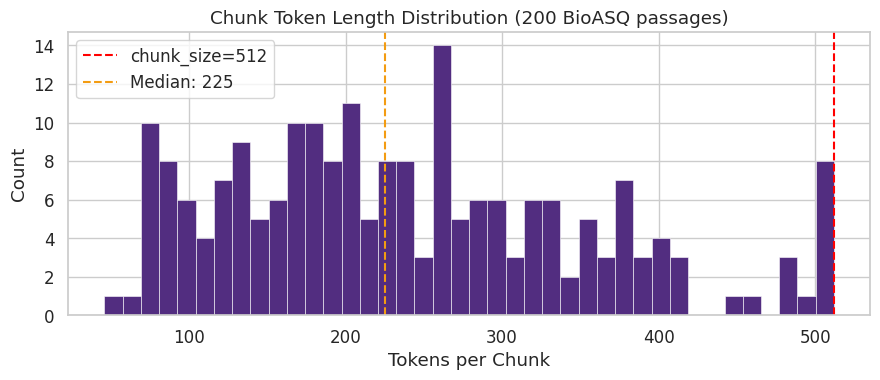

Passages analysed        : 200
Total chunks             : 207
Avg chunks per passage   : 1.03
Max chunk token length   : 512
All chunks ≤ 512 tokens  : True

Actual avg chunks/passage for the full 27,972-passage corpus: 30850/27972 = 1.10


In [10]:
# ── Chunker: verify chunk counts and overlap ──────────────────────
chunker = TokenChunker(chunk_size=512, chunk_overlap=64)

# Use first 200 BioASQ passages to measure real chunk statistics
sample_passages = corpus[:200]
all_chunks = []
for p in sample_passages:
    all_chunks.extend(chunker.chunk(p["text"], doc_id=p["id"],
                                    metadata={"dataset": "bioasq"}))

chunk_token_lengths = [len(enc.encode(c.text)) for c in all_chunks]

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(chunk_token_lengths, bins=40, color=PURPLE, edgecolor="white", linewidth=0.4)
ax.axvline(512, color="red", linestyle="--", label="chunk_size=512")
ax.axvline(np.median(chunk_token_lengths), color=AMBER, linestyle="--",
           label=f"Median: {np.median(chunk_token_lengths):.0f}")
ax.set_title("Chunk Token Length Distribution (200 BioASQ passages)")
ax.set_xlabel("Tokens per Chunk")
ax.set_ylabel("Count")
ax.legend()
plt.tight_layout()
plt.savefig("../experiments/results/fig_chunk_lengths.png", dpi=150, bbox_inches="tight")
plt.show()

avg_chunks_per_passage = len(all_chunks) / len(sample_passages)
print(f"Passages analysed        : {len(sample_passages)}")
print(f"Total chunks             : {len(all_chunks)}")
print(f"Avg chunks per passage   : {avg_chunks_per_passage:.2f}")
print(f"Max chunk token length   : {max(chunk_token_lengths)}")
print(f"All chunks \u2264 512 tokens  : {all(l <= 512 for l in chunk_token_lengths)}")
print(f"\nActual avg chunks/passage for the full 27,972-passage corpus: 30850/27972 = {30850/27972:.2f}")


In [11]:
# ── Verify chunk overlap ────────────────────────────────────────
# The last 64 tokens of chunk N should appear as the first 64 tokens of chunk N+1.
# The test passage must exceed chunk_size (512 tokens) or the chunker will
# correctly return a single chunk and this check never exercises anything.
test_passage = "word " * 1000
test_chunks  = chunker.chunk(test_passage, doc_id="overlap_test")

print(f"Test passage: {len(enc.encode(test_passage))} tokens")
print(f"Chunks produced: {len(test_chunks)}")
for i, c in enumerate(test_chunks):
    n_tokens = len(enc.encode(c.text))
    print(f"  Chunk {i}: tokens [{c.start_token}, {c.end_token}) \u2014 {n_tokens} tokens")

if len(test_chunks) >= 2:
    gap = test_chunks[1].start_token - test_chunks[0].start_token
    stride = chunker.chunk_size - chunker.chunk_overlap
    print(f"\nExpected stride (chunk_size - overlap) : {stride}")
    print(f"Actual stride between chunk 0 and 1   : {gap}")
    print(f"Overlap correct: {gap == stride}")
else:
    print("\nOnly 1 chunk produced \u2014 overlap not exercised.")


Test passage: 1001 tokens
Chunks produced: 3
  Chunk 0: tokens [0, 512) — 512 tokens
  Chunk 1: tokens [448, 960) — 512 tokens
  Chunk 2: tokens [896, 1001) — 105 tokens

Expected stride (chunk_size - overlap) : 448
Actual stride between chunk 0 and 1   : 448
Overlap correct: True


## 5. Ingested Corpus Analysis

In [12]:
# ── ChromaDB collection statistics ─────────────────────────────
from pipeline.vectorstore import get_vector_store

store = get_vector_store()
info  = store.collection_info()

print("ChromaDB Collection Info:")
for k, v in info.items():
    print(f"  {k:<22} : {v}")


2026-08-13 04:29:06.981 | INFO     | pipeline.vectorstore:__init__:110 - Connecting to ChromaDB at chromadb:8000 …


2026-08-13 04:29:07.134 | INFO     | pipeline.vectorstore:__init__:122 - ChromaDB collection 'ragscope_corpus' ready. Current count: 30,850 chunks.


ChromaDB Collection Info:
  collection_name        : ragscope_corpus
  chunk_count            : 30850
  chroma_host            : chromadb
  chroma_port            : 8000


2026-08-13 04:29:11.960 | INFO     | pipeline.ingestion:load_bm25_corpus:313 - BM25 corpus loaded: 30,850 entries.


BM25 corpus path   : /app/data/bm25_corpus.jsonl
BM25 entries       : 30,850
File size          : 41.8 MB


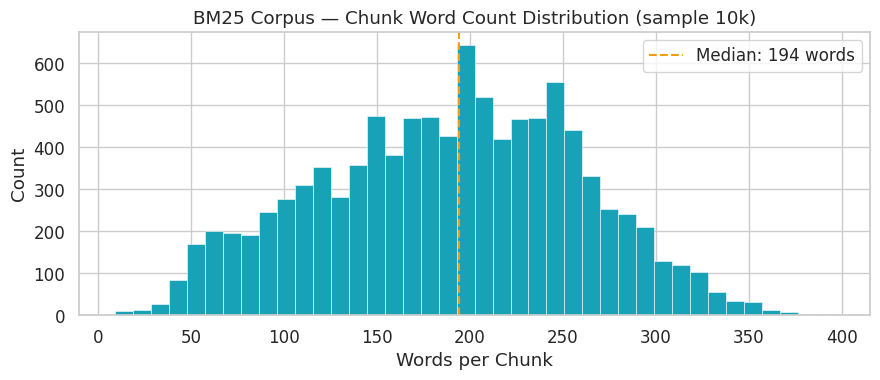

In [13]:
# ── BM25 corpus statistics ─────────────────────────────────
from pipeline.ingestion import load_bm25_corpus, BM25_CORPUS_PATH

bm25_ids, bm25_texts = load_bm25_corpus()

print(f"BM25 corpus path   : {BM25_CORPUS_PATH}")
print(f"BM25 entries       : {len(bm25_ids):,}")
print(f"File size          : {BM25_CORPUS_PATH.stat().st_size / 1024 / 1024:.1f} MB")

sample_word_counts = [len(t.split()) for t in bm25_texts[:10_000]]

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(sample_word_counts, bins=40, color=TEAL, edgecolor="white", linewidth=0.4)
ax.axvline(np.median(sample_word_counts), color=AMBER, linestyle="--",
           label=f"Median: {np.median(sample_word_counts):.0f} words")
ax.set_title("BM25 Corpus \u2014 Chunk Word Count Distribution (sample 10k)")
ax.set_xlabel("Words per Chunk")
ax.set_ylabel("Count")
ax.legend()
plt.tight_layout()
plt.savefig("../experiments/results/fig_bm25_word_counts.png", dpi=150, bbox_inches="tight")
plt.show()


In [14]:
# ── Ingestion manifest review ─────────────────────────────
from pipeline.ingestion import MANIFEST_PATH
import json

if MANIFEST_PATH.exists():
    manifest = json.loads(MANIFEST_PATH.read_text())
    print("Ingestion Manifest:")
    print(f"  Corpus          : {manifest['corpus']}")
    print(f"  Started at      : {manifest['started_at']}")
    print(f"  Finished at     : {manifest['finished_at']}")
    print(f"  Total passages  : {manifest['total_passages']:,}")
    print(f"  Total chunks    : {manifest['total_chunks']:,}")
    print(f"  Chunks upserted : {manifest['total_upserted']:,}")
    print(f"  BM25 entries    : {manifest['bm25_entries']:,}")
    print(f"  Elapsed         : {manifest['elapsed_seconds']}s")
    print()
    print("  Per-dataset breakdown:")
    for ds in manifest.get("per_dataset", []):
        print(f"    {ds['dataset']:<22} passages={ds['passages_loaded']:>6,} "
              f"skipped={ds['passages_skipped']:>4,} "
              f"chunks={ds['chunks_created']:>7,}")
else:
    print(f"Manifest not found at {MANIFEST_PATH}. Run ingestion first.")


Ingestion Manifest:
  Corpus          : bioasq
  Started at      : 2026-08-13T03:27:31.208798+00:00
  Finished at     : 2026-08-13T03:30:10.404043+00:00
  Total passages  : 27,972
  Total chunks    : 30,850
  Chunks upserted : 30,850
  BM25 entries    : 30,850
  Elapsed         : 159.2s

  Per-dataset breakdown:
    bioasq                 passages=27,972 skipped=   0 chunks= 30,850


## 6. Benchmark Query Set Validation

In [15]:
from evaluation.benchmark import load_benchmark

benchmark = load_benchmark(seed=SEED)
bm_df = pd.DataFrame(benchmark)

print(f"Total benchmark queries : {len(bm_df)}")
print()
print("By role (dataset field):")
print(bm_df["dataset"].value_counts().to_string())
print()
print("By query_type:")
print(bm_df["query_type"].value_counts().to_string())


2026-08-13 04:29:12.127 | INFO     | evaluation.benchmark:load_benchmark:39 - Loading benchmark queries …


2026-08-13 04:29:13.271 | DEBUG    | data.loaders.bioasq:_build_role_pools:299 - BioASQ role pools built: factoid=256, yesno=802, summary_long=50, phase_a_single=677, phase_a_multi=2934.


2026-08-13 04:29:13.272 | INFO     | data.loaders.bioasq:load_phase_a_queries:159 - BioASQ Phase A queries loaded: 30 single-relevant, 30 multi-relevant.


2026-08-13 04:29:14.114 | DEBUG    | data.loaders.bioasq:_build_role_pools:299 - BioASQ role pools built: factoid=256, yesno=802, summary_long=50, phase_a_single=677, phase_a_multi=2934.


2026-08-13 04:29:14.114 | INFO     | data.loaders.bioasq:load_factoid_queries:183 - BioASQ factoid queries loaded: 40.


2026-08-13 04:29:14.944 | DEBUG    | data.loaders.bioasq:_build_role_pools:299 - BioASQ role pools built: factoid=256, yesno=802, summary_long=50, phase_a_single=677, phase_a_multi=2934.


2026-08-13 04:29:14.945 | INFO     | data.loaders.bioasq:load_summary_queries:213 - BioASQ summary queries loaded: 50 yes/no, 50 summary.


2026-08-13 04:29:14.946 | INFO     | evaluation.benchmark:load_benchmark:49 - Benchmark assembled: 60 Phase A + 40 factoid + 100 summary = 200 total queries.


Total benchmark queries : 200

By role (dataset field):
dataset
bioasq_summary    100
bioasq_phase_a     60
bioasq_factoid     40

By query_type:
query_type
summary            50
yesno              50
factoid            40
multi_relevant     30
single_relevant    30


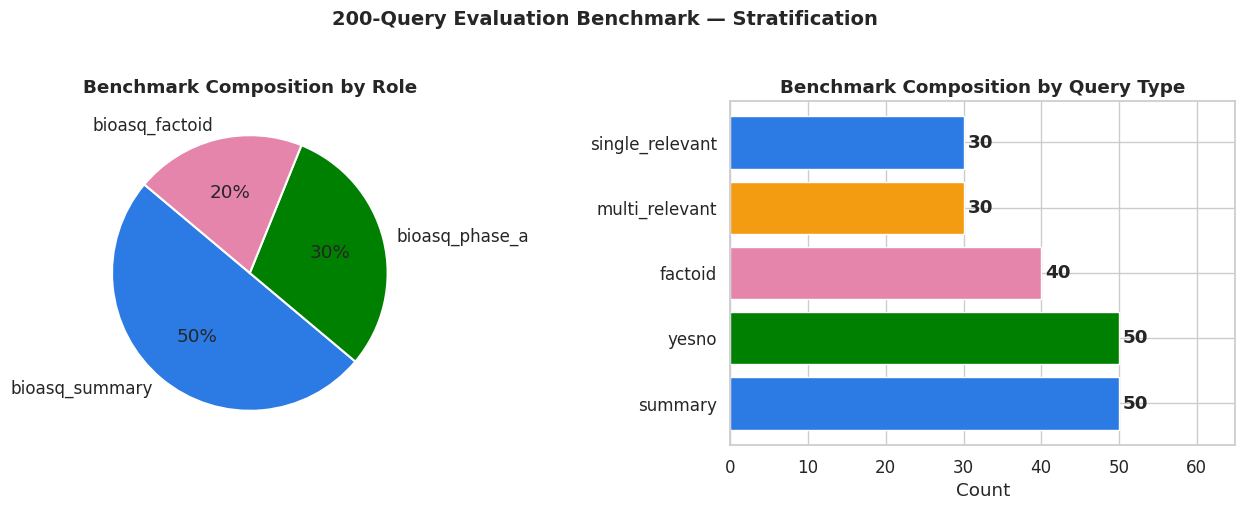


Ground truth coverage: 200/200 queries (100%)


In [16]:
# ── Benchmark stratification visualisation ─────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Pie: by role
role_counts = bm_df["dataset"].value_counts()
axes[0].pie(role_counts, labels=role_counts.index, autopct="%1.0f%%",
            colors=PALETTE[:len(role_counts)], startangle=140,
            wedgeprops={"edgecolor": "white", "linewidth": 1.5})
axes[0].set_title("Benchmark Composition by Role", fontweight="bold")

# Bar: by query_type
qt_counts = bm_df["query_type"].value_counts()
bars = axes[1].barh(qt_counts.index, qt_counts.values,
                    color=PALETTE[:len(qt_counts)], edgecolor="white")
for bar, v in zip(bars, qt_counts.values):
    axes[1].text(v + 0.5, bar.get_y() + bar.get_height()/2,
                 str(v), va="center", fontweight="bold")
axes[1].set_title("Benchmark Composition by Query Type", fontweight="bold")
axes[1].set_xlabel("Count")
axes[1].set_xlim(0, 65)

plt.suptitle("200-Query Evaluation Benchmark \u2014 Stratification",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("../experiments/results/fig_benchmark_stratification.png",
            dpi=150, bbox_inches="tight")
plt.show()

has_gt = bm_df["answers"].apply(lambda x: bool(x and x[0]))
print(f"\nGround truth coverage: {has_gt.sum()}/{len(bm_df)} queries ({has_gt.mean()*100:.0f}%)")


## 7. Corpus Cleaning Analysis

BioASQ is indexed as a single, unified corpus — there is no per-source imbalance to analyse. The more interesting composition question for this dataset turns out to be a data-quality one: a substantial fraction of the raw HuggingFace mirror consists of literal `"nan"` placeholder strings rather than real passage text.

data/passages.parquet/part.0.parquet:   0%|          | 0.00/24.5M [00:00<?, ?B/s]

Generating passages split:   0%|          | 0/40221 [00:00<?, ? examples/s]

                          Category  Count Share
               Kept (real passage)  27972 69.5%
                 "nan" placeholder  12220 30.4%
Other (too short / low-alphabetic)     29  0.1%


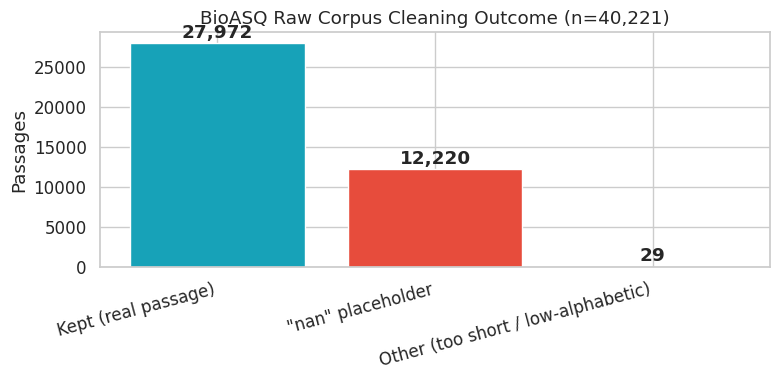


Confirmed: 27,972 + 12,220 + 29 = 40,221


In [17]:
# ── Corpus cleaning breakdown: raw vs. kept vs. "nan" artefact vs. other ────
from datasets import load_dataset

raw_ds = load_dataset("rag-datasets/rag-mini-bioasq", name="text-corpus")["passages"]
raw_total = len(raw_ds)
nan_count = sum(1 for ex in raw_ds if ex["passage"].strip().lower() == "nan")
kept_count = len(corpus)
other_dropped = raw_total - nan_count - kept_count

cleaning = pd.DataFrame([
    {"Category": "Kept (real passage)", "Count": kept_count, "Share": kept_count / raw_total},
    {"Category": '"nan" placeholder', "Count": nan_count, "Share": nan_count / raw_total},
    {"Category": "Other (too short / low-alphabetic)", "Count": other_dropped, "Share": other_dropped / raw_total},
])
print(cleaning.to_string(index=False, formatters={"Share": "{:.1%}".format}))

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(cleaning["Category"], cleaning["Count"], color=[TEAL, RED, "#95a5a6"], edgecolor="white")
for bar, count in zip(bars, cleaning["Count"]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
            f"{count:,}", ha="center", va="bottom", fontweight="bold")
ax.set_title(f"BioASQ Raw Corpus Cleaning Outcome (n={raw_total:,})")
ax.set_ylabel("Passages")
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.savefig("../experiments/results/fig_bioasq_cleaning.png", dpi=150, bbox_inches="tight")
plt.show()

assert kept_count + nan_count + other_dropped == raw_total
print(f"\nConfirmed: {kept_count:,} + {nan_count:,} + {other_dropped:,} = {raw_total:,}")


In [18]:
# ── Summary table ─────────────────────────────────────────
summary = pd.DataFrame([
    {
        "Role":            "Phase A",
        "Query Type":      "Passage retrieval",
        "Benchmark Qs":    len(phase_a_queries),
        "Avg Q Words":     round(pd.Series([len(q["query"].split()) for q in phase_a_queries]).mean(), 1),
        "Has Ground Truth": "Yes (answers field)",
    },
    {
        "Role":            "Factoid",
        "Query Type":      "Short exact-answer QA",
        "Benchmark Qs":    len(factoid_queries),
        "Avg Q Words":     round(pd.Series([len(q["query"].split()) for q in factoid_queries]).mean(), 1),
        "Has Ground Truth": "Yes (answers field, \u2264 6 words)",
    },
    {
        "Role":            "Summary",
        "Query Type":      "Multi-passage synthesis",
        "Benchmark Qs":    len(summary_queries),
        "Avg Q Words":     round(pd.Series([len(q["query"].split()) for q in summary_queries]).mean(), 1),
        "Has Ground Truth": "Yes (answers field)",
    },
])
print("\n=== BioASQ Role Summary ===")
print(summary.to_string(index=False))
print(f"\nCorpus: {len(corpus):,} passages (single unified BioASQ corpus)")
print(f"Licence: CC BY 2.5 (rag-datasets/rag-mini-bioasq)")



=== BioASQ Role Summary ===
   Role              Query Type  Benchmark Qs  Avg Q Words               Has Ground Truth
Phase A       Passage retrieval            60          9.3            Yes (answers field)
Factoid   Short exact-answer QA            40          7.6 Yes (answers field, ≤ 6 words)
Summary Multi-passage synthesis           100          8.7            Yes (answers field)

Corpus: 27,972 passages (single unified BioASQ corpus)
Licence: CC BY 2.5 (rag-datasets/rag-mini-bioasq)


## 8. Key Findings

| Observation | Implication for the Experiment |
|---|---|
| 30.4% of the raw BioASQ corpus mirror consists of literal `"nan"` placeholder strings | The meaningfulness filter is load-bearing for this dataset, not just a defensive guard — confirmed by direct inspection, not assumed |
| BioASQ passages average 1.10 chunks/passage | A modest share of longer PubMed abstracts split into 2 chunks; no change to the 512/64 chunking configuration was needed |
| Factoid answers are all ≤ 6 words by construction | RAGAS `answer_correctness` scoring relies on semantic embeddings — short answers may score unpredictably |
| Summary yes/no answers are prefixed sentences (e.g. "Yes, papilin is a secreted protein"), not bare "yes"/"no" | Faithfulness scoring's atomic-claim decomposition is reasonably well-defined here, but short binary-leaning answers still warrant caution in correctness scoring |
| All 200 benchmark queries have a ground-truth answer | Full RAGAS `answer_correctness` computation is possible for all queries |
| The three role pools are verified disjoint at seed 42 | No question is double-counted across roles; the 60/40/100 split sums to exactly 200 unique queries |
| The benchmark is 60/40/100 across Phase A/Factoid/Summary | Summary (multi-passage synthesis) queries are weighted most heavily \u2014 the hardest condition for faithfulness |

---

*Next notebook: `02_retrieval_strategy_comparison.ipynb` — comparing dense vs. hybrid retrieval across all conditions.*